Text(0.5, 0, 'Time (ms)')

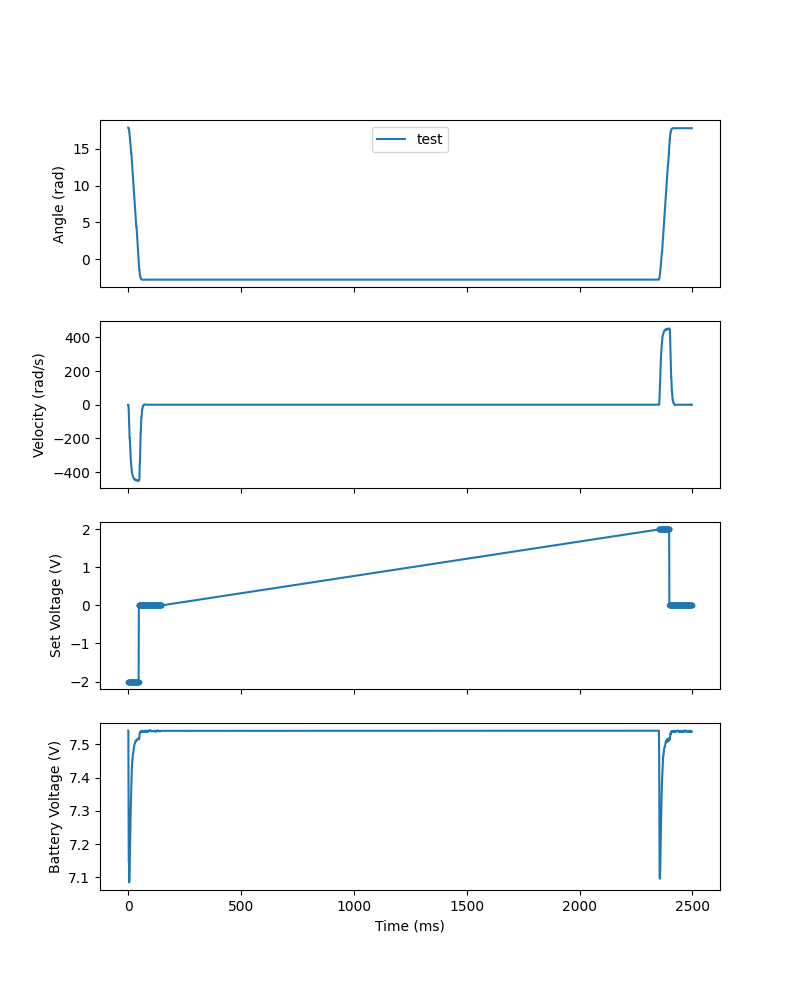

In [6]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
%matplotlib widget

fig, axs = plt.subplots(4,1, figsize=(8,10), sharex=True)  # Increased to 4 subplots

#6,5,7
#4,3,2

# log_files = glob.glob('experiment_data/log/jump*.csv')
# log_files.append('motor_logs/motor_log_20260109_005623.csv')
# log_files.sort(key=os.path.getmtime, reverse=True)

log_files = [
    'motor_logs/test.csv'
]
for log_file in log_files:
    if log_file[-9:] == 'short.csv':
        continue

    df = pd.read_csv(log_file)

    axs[0].plot(df['time_ms']-df['time_ms'][0], df['angle'], '-', label=log_file[11:-4])
    
    ln, = axs[1].plot(df['time_ms']-df['time_ms'][0], df['vel'], '-', label=log_file[11:-4])
    color = ln.get_color()
    setvolt = df['set_volts'].iloc[0]
    freespeed = 2200*2*np.pi/60 * setvolt
    # axs[1].plot(df['time_ms']-df['time_ms'][0], freespeed*np.ones_like(df['vel']), '--', color=color)

    axs[2].plot(df['time_ms']-df['time_ms'][0], df['set_volts'], '.-', label=log_file[11:-4])

    axs[3].plot(df['time_ms']-df['time_ms'][0], df['vbat'], '-', label=log_file[11:-4])


axs[0].legend()

# Updated axis labels
axs[0].set_ylabel('Angle (rad)')
axs[1].set_ylabel('Velocity (rad/s)')
axs[2].set_ylabel('Set Voltage (V)')
axs[3].set_ylabel('Battery Voltage (V)')
axs[3].set_xlabel('Time (ms)')